In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading xLSTM 7B...")
xlstm_config = AutoConfig.from_pretrained("NX-AI/xLSTM-7b")
xlstm_config.step_kernel = "native"
xlstm_config.chunkwise_kernel = "chunkwise--native_autograd"
xlstm_config.sequence_kernel = "native_sequence__native"

model = AutoModelForCausalLM.from_pretrained("NX-AI/xLSTM-7b", config=xlstm_config, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained("NX-AI/xLSTM-7b")
tokenizer.pad_token = tokenizer.eos_token

Loading xLSTM 7B...


Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


In [2]:
print(model)

xLSTMForCausalLM(
  (backbone): xLSTMModel(
    (embeddings): Embedding(50304, 4096)
    (blocks): ModuleList(
      (0-31): 32 x xLSTMBlock(
        (norm_mlstm): xLSTMRMSNorm()
        (mlstm_layer): xLSTMLayer(
          (q): Linear(in_features=4096, out_features=2048, bias=False)
          (k): Linear(in_features=4096, out_features=2048, bias=False)
          (v): Linear(in_features=4096, out_features=4096, bias=False)
          (ogate_preact): Linear(in_features=4096, out_features=4096, bias=False)
          (igate_preact): Linear(in_features=4096, out_features=8, bias=True)
          (fgate_preact): Linear(in_features=4096, out_features=8, bias=True)
          (ogate_act_fn): Sigmoid()
          (mlstm_backend): xLSTMBackend(
            xLSTMConfig {
              "add_embedding_dropout": false,
              "add_forward_backend_padding": false,
              "add_out_norm": true,
              "add_post_blocks_norm": true,
              "add_post_norm": false,
              "a

In [3]:
# Your prompt
prompt = "Well, Prince, so Genoa and Lucca are now just family estates of the Buonapartes. But I warn you, if you don't tell me that this means war, if you still try to defend the infamies and horrors perpetrated by that Antichrist. I really believe he is Antichrist. I will have nothing more to do with you and you are no longer my friend, no longer my faithful slave, as you call yourself! But how do you do? I see I have frightened you! Sit down and tell me all the news. It was in July, 1805, and the speaker was the well known Anna Pavlovna Scherer, maid of honor and favorite of the Empress Marya Fedorovna. With these words she greeted Prince Vasili Kuragin, a man of high rank and importance, who was the first to arrive at her reception."

# prompt = "The quick brown fox jumps over the lazy dog."
# Tokenize and send to the same device as the model
input_ids = tokenizer(prompt, return_tensors="pt")['input_ids'].to(model.device)

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers.models.xlstm.modeling_xlstm import soft_cap


# ---------------------------------------------------------------------------
# 1. Hook every mLSTM layer to capture its input x_mlstm
# ---------------------------------------------------------------------------
xs = {}
hooks = []
for ell, block in enumerate(model.backbone.blocks):
    def pre_hook(module, args, kwargs, ell=ell):
        x = args[0] if args else kwargs["x"]
        xs[ell] = x.detach()
    hooks.append(block.mlstm_layer.register_forward_pre_hook(pre_hook, with_kwargs=True))

with torch.no_grad():
    model(input_ids=input_ids)

for h in hooks:
    h.remove()

In [5]:
import gc

# 1. Turn off gradients so PyTorch doesn't save the massive computation graph!
torch.set_grad_enabled(False)

L = len(model.backbone.blocks) # 32
B, T = xs[0].shape[:2]
b = 0  # batch index of interest

Cfro_all = []   # list of (B, H, T) per layer
C_matrix_all = []  

for layer_idx in range(L):
    layer = model.backbone.blocks[layer_idx].mlstm_layer
    cfg   = layer.config
    H, cap = cfg.num_heads, cfg.gate_soft_cap

    x = xs[layer_idx].float()                         # (B, T, D)
    dqk = cfg.qk_dim // H # Dimension for Q and K
    dv  = cfg.v_dim  // H # Dimension for V 

    # gate pre-activations + K/V (single or fused weight mode)
    if cfg.weight_mode == "single":
        i_hat  = soft_cap(layer.igate_preact(x), cap)
        f_hat  = soft_cap(layer.fgate_preact(x), cap)
        k_proj = layer.k(x)
        v_proj = layer.v(x)
    else:
        ifp = soft_cap(layer.ifgate_preact(x), cap)
        i_hat, f_hat = torch.tensor_split(ifp, (H,), dim=-1)
        qkvo = layer.qkv_opreact(x)
        _, k_proj, v_proj, _ = torch.tensor_split(
            qkvo, (cfg.qk_dim, 2 * cfg.qk_dim, 2 * cfg.qk_dim + cfg.v_dim), dim=-1
        )

    i_hat = i_hat.transpose(1, 2).float()                                  # (B, H, T)
    f_hat = f_hat.transpose(1, 2).float()
    k = k_proj.reshape(B, T, H, dqk).permute(0, 2, 1, 3).float()           # (B, H, T, dqk)
    v = v_proj.reshape(B, T, H, dv ).permute(0, 2, 1, 3).float()           # (B, H, T, dv)

    # rolling mLSTM state
    C = torch.zeros(B, H, dqk, dv, device=x.device)
    m = torch.zeros(B, H, 1,       device=x.device)

    C_fro = torch.empty(B, H, T, device=x.device) # Frobenius norm of the cell state
    # We will store the mean of C across heads for this layer to save memory
    C_layer_time = torch.empty(B, T, dqk, dv, device='cpu') # Shape: (1, 188, 64, 64)
    
    for t in range(T):
        i_t   = i_hat[:, :, t:t+1]
        f_t   = f_hat[:, :, t:t+1]
        f_log = F.logsigmoid(f_t)
        m_new = torch.maximum(f_log + m, i_t)
        ibar_t = torch.exp(i_t   - m_new)                                  # (B, H, 1)
        fbar_t = torch.exp(f_log + m - m_new)

        k_t = k[:, :, t, :]                                                # (B, H, dqk)
        v_t = v[:, :, t, :]                                                # (B, H, dv)
        kv  = k_t.unsqueeze(-1) * v_t.unsqueeze(-2)                        # (B, H, dqk, dv)

        C = fbar_t.unsqueeze(-1) * C + ibar_t.unsqueeze(-1) * kv
        m = m_new

        C_fro[:, :, t] = C.flatten(2).norm(dim=-1)
        C_layer_time[0, t] = C[0].mean(dim=0).cpu() 

    Cfro_all.append(C_fro.cpu())
    C_matrix_all.append(C_layer_time) 
    # 2. Free up memory at the end of each layer!
    del x, i_hat, f_hat, k_proj, v_proj, k, v, C, m, C_fro, kv
    if cfg.weight_mode != "single":
        del ifp, qkvo
    
    # 3. Force PyTorch to release the VRAM back to the system
    gc.collect()
    torch.cuda.empty_cache()

Cfro_all = torch.stack(Cfro_all, dim=0)                                    # (L, B, H, T)
C_matrix_all = torch.stack(C_matrix_all, dim=0)

# Reductions for plotting
Cfro_per_block   = Cfro_all[:, b].mean(dim=1)                              # (L, T) heatmap
Cfro_token_amean = Cfro_all[:, b].mean(dim=(0, 1))                         # (T,)

tokens = tokenizer.convert_ids_to_tokens(input_ids[b].tolist())
tokens = [t.replace("Ġ", " ").replace("▁", " ") for t in tokens]

# Turn gradients back on just in case you need them later
torch.set_grad_enabled(True)


torch.autograd.grad_mode.set_grad_enabled(mode=True)

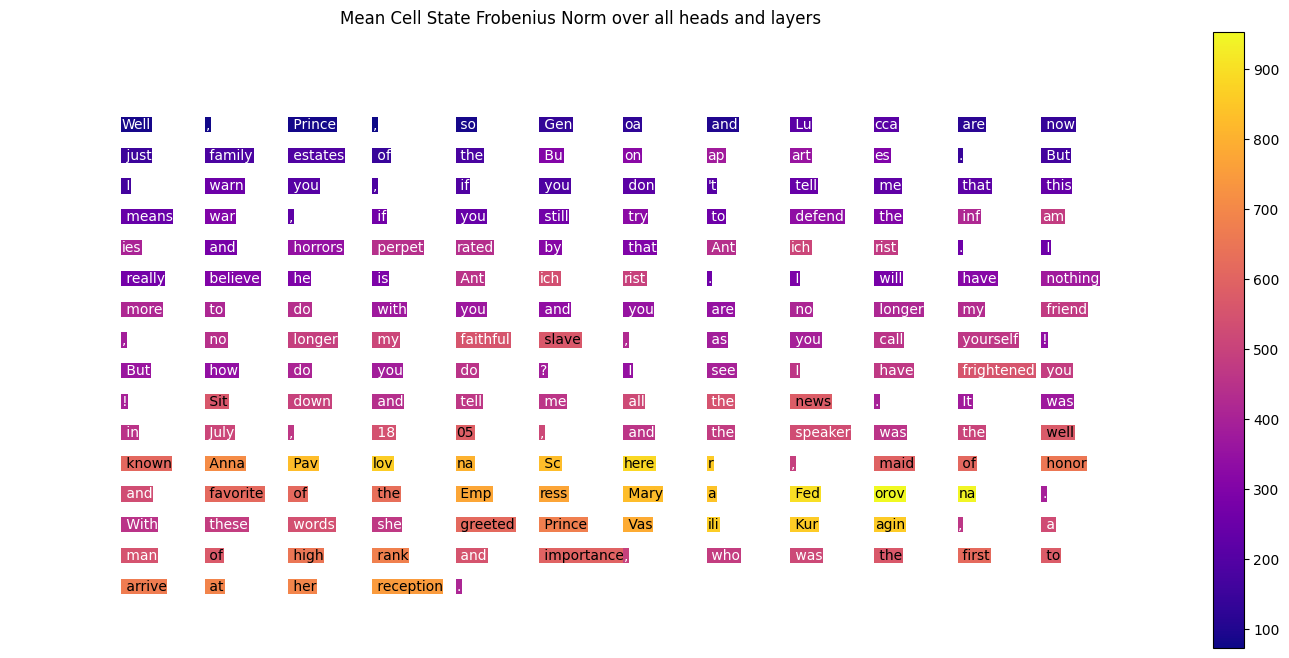

In [6]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def colored_text(values, tokens, cmap_name, title,
                 vmin=None, vmax=None,
                 tokens_per_row=20, fig_width=16, save_path=None, show=True):
    vmin = float(values.min()) if vmin is None else vmin
    vmax = float(values.max()) if vmax is None else vmax
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)

    n = len(tokens)
    n_rows = (n + tokens_per_row - 1) // tokens_per_row

    fig, ax = plt.subplots(figsize=(fig_width, n_rows / 2))
    ax.set_axis_off()
    ax.set_title(title)

    x_start, x_end = 0.01, 0.89
    row_height = 0.05

    for i, (tok, val) in enumerate(zip(tokens, values)):
        row = i // tokens_per_row
        col = i % tokens_per_row
        x = x_start + (x_end - x_start) * (col / tokens_per_row + 0.1)
        y = 1 - (row + 3) * row_height
        rgba = cmap(norm(val))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "white" if luminance < 0.5 else "black"
        
        ax.text(x, y, tok, transform=ax.transAxes,
                va="center", color=text_color,
                bbox=dict(facecolor=rgba, edgecolor="none", pad=0.5))

    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),
                        ax=ax, fraction=0.03)

    if save_path:
        plt.savefig(save_path)

    if show:
        plt.show()

# Plot the Cell State Frobenius Norm
colored_text(
    Cfro_token_amean, 
    tokens, 
    "plasma", # You can change this to "Greens", "Reds", "viridis", etc.
    r"Mean Cell State Frobenius Norm over all heads and layers",
    tokens_per_row=12
)


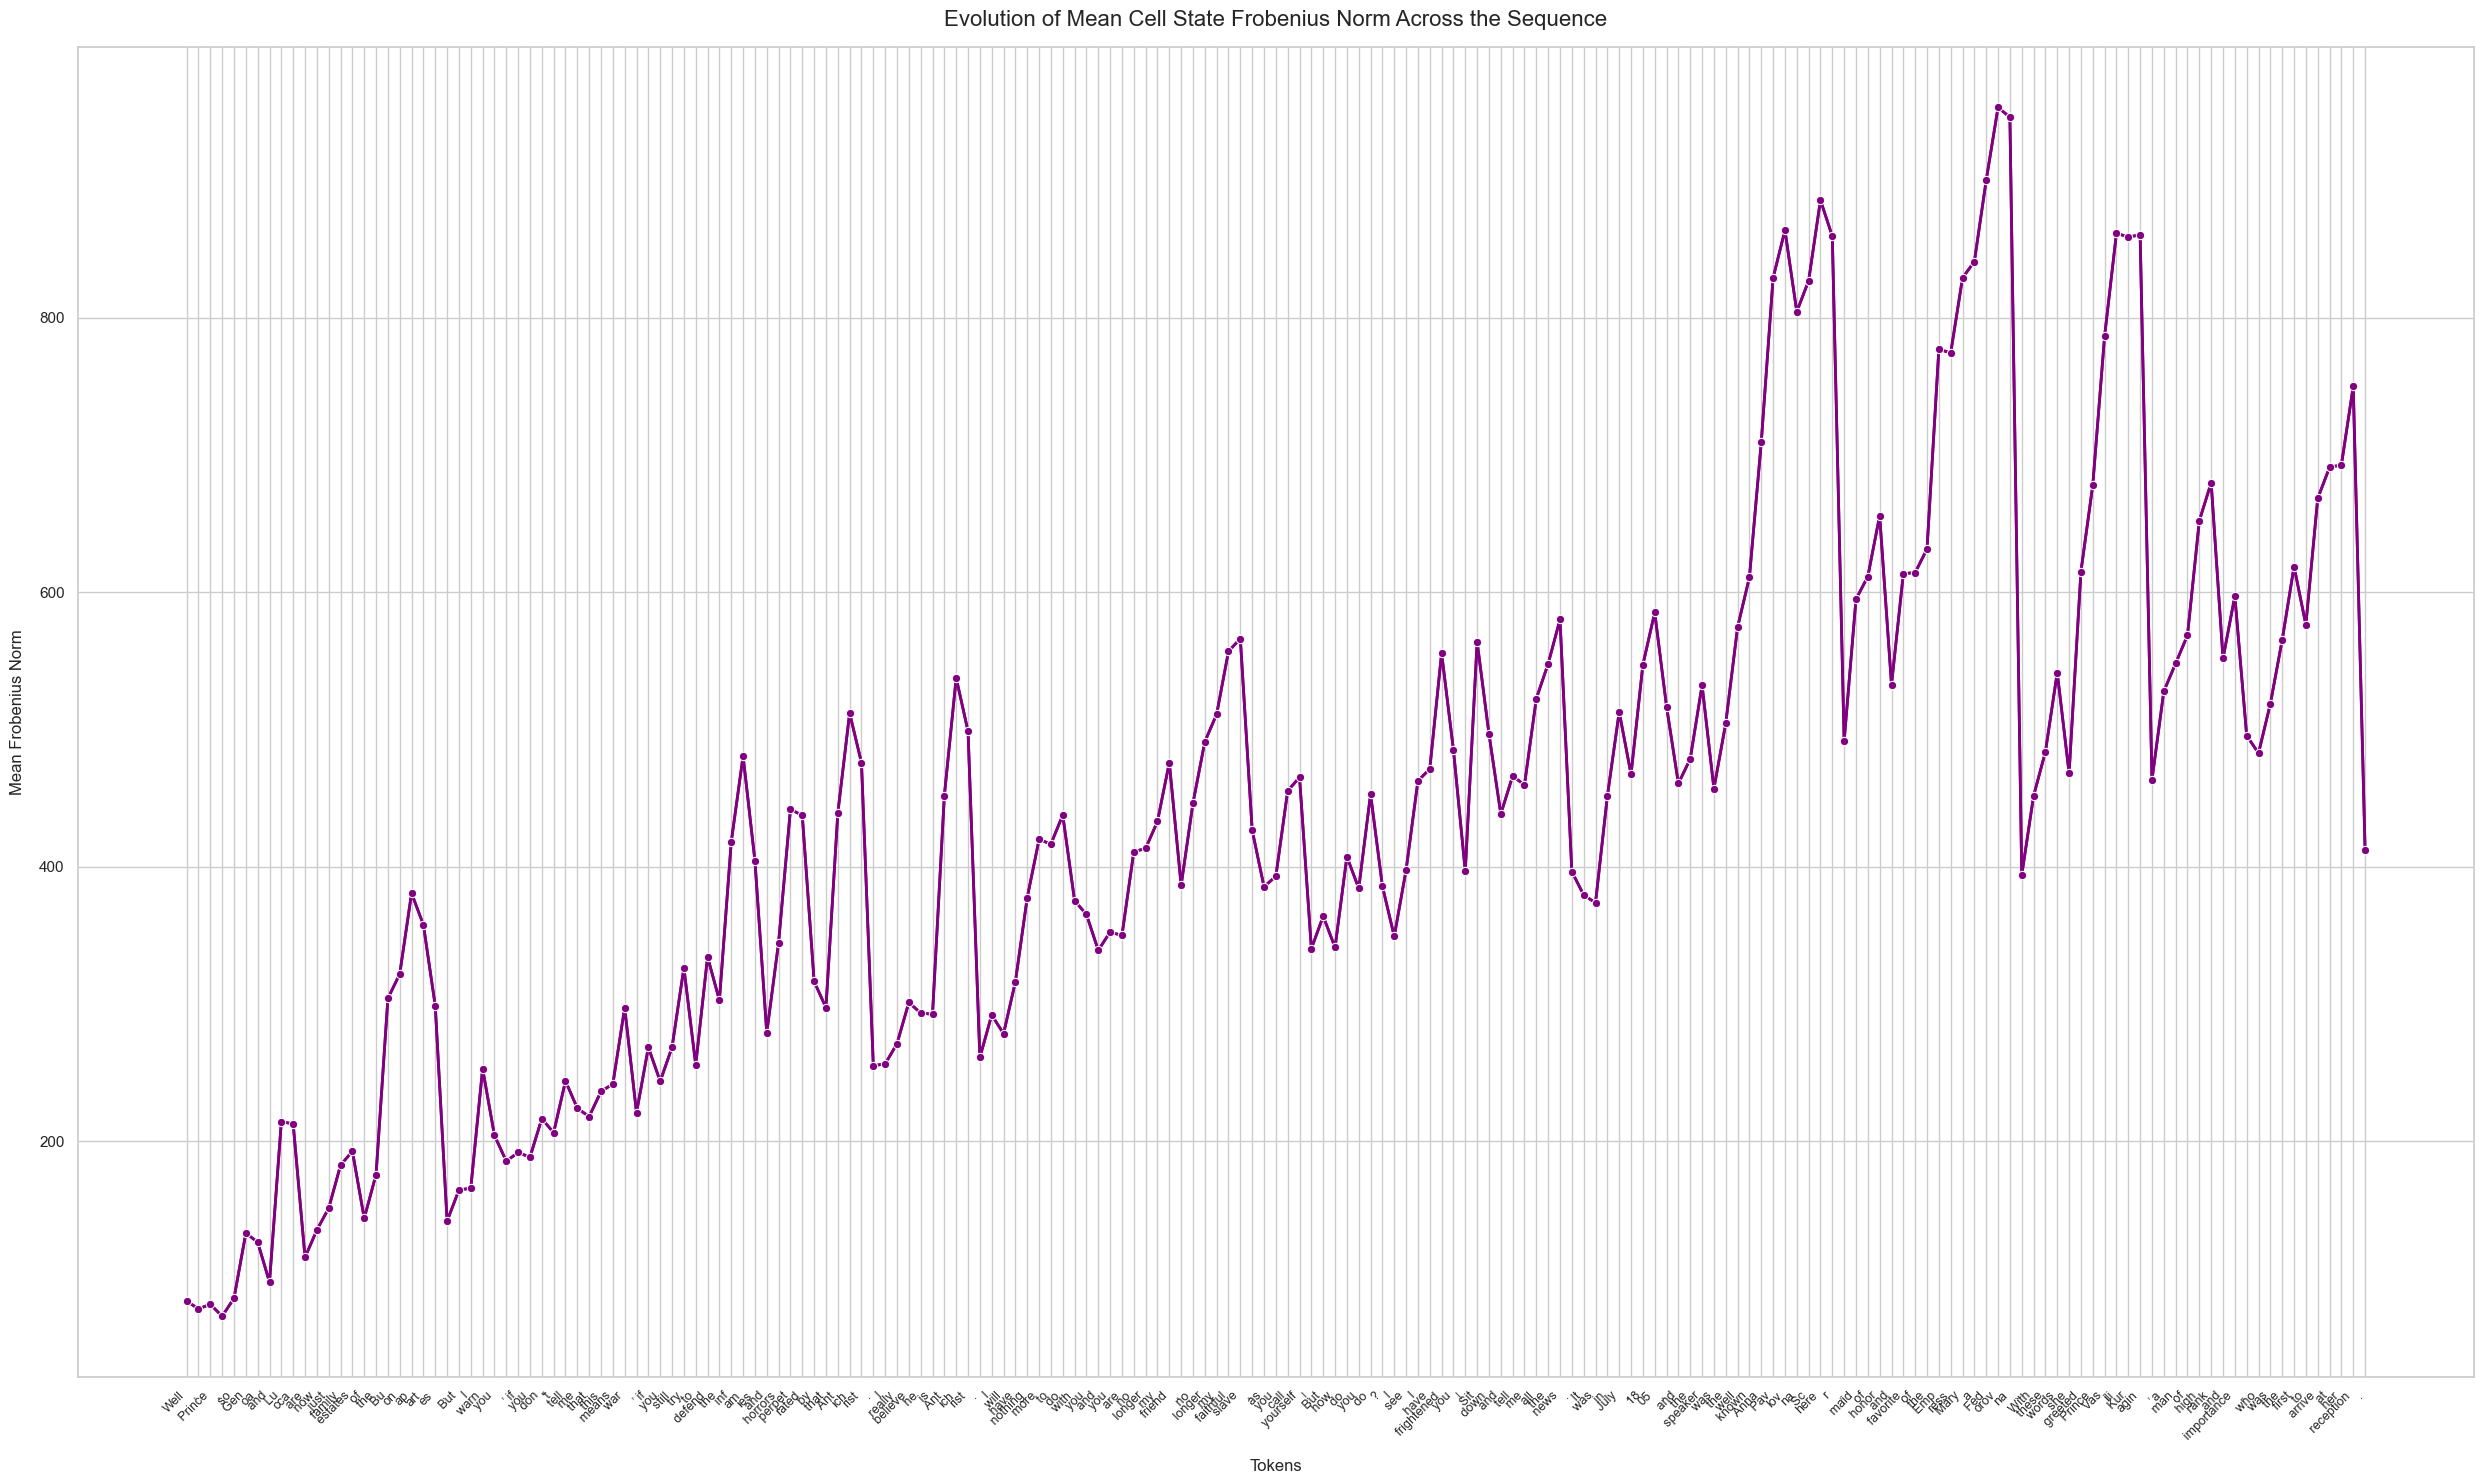

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a DataFrame for Seaborn
df = pd.DataFrame({
    'Token Index': range(len(tokens)),
    'Token': tokens,
    'Mean Cell State Norm': Cfro_token_amean.numpy()  # Convert from tensor to numpy array
})

# 2. Set the Seaborn style
sns.set_theme(style="whitegrid")

# 3. Create the plot

plt.figure(figsize=(25, 15)) 
ax = sns.lineplot(
    data=df, 
    x='Token Index', 
    y='Mean Cell State Norm', 
    marker="o", 
    color="purple",
    linewidth=2,
    markersize=6
)
ax.set_xticks(range(len(tokens)))
# Change rotation to 60 degrees (from 45) so the words stack a bit tighter vertically, 
# preventing long words from overlapping the word next to them
ax.set_xticklabels(tokens, rotation=60, ha='right', fontsize=9)

# A lineplot with markers is usually best for sequence data
ax = sns.lineplot(
    data=df, 
    x='Token Index', 
    y='Mean Cell State Norm', 
    marker="o", 
    color="purple",
    linewidth=2,
    markersize=6
)

# 4. Format the X-axis to show the actual tokens tilted at 45 degrees
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)

# 5. Add labels and a title
plt.title("Evolution of Mean Cell State Frobenius Norm Across the Sequence", fontsize=16, pad=15)
plt.xlabel("Tokens", fontsize=12, labelpad=10)
plt.ylabel("Mean Frobenius Norm", fontsize=12, labelpad=10)

# Optional: Tight layout ensures the tilted labels don't get cut off when saving/displaying
plt.tight_layout()

# Show the plot!
plt.show()


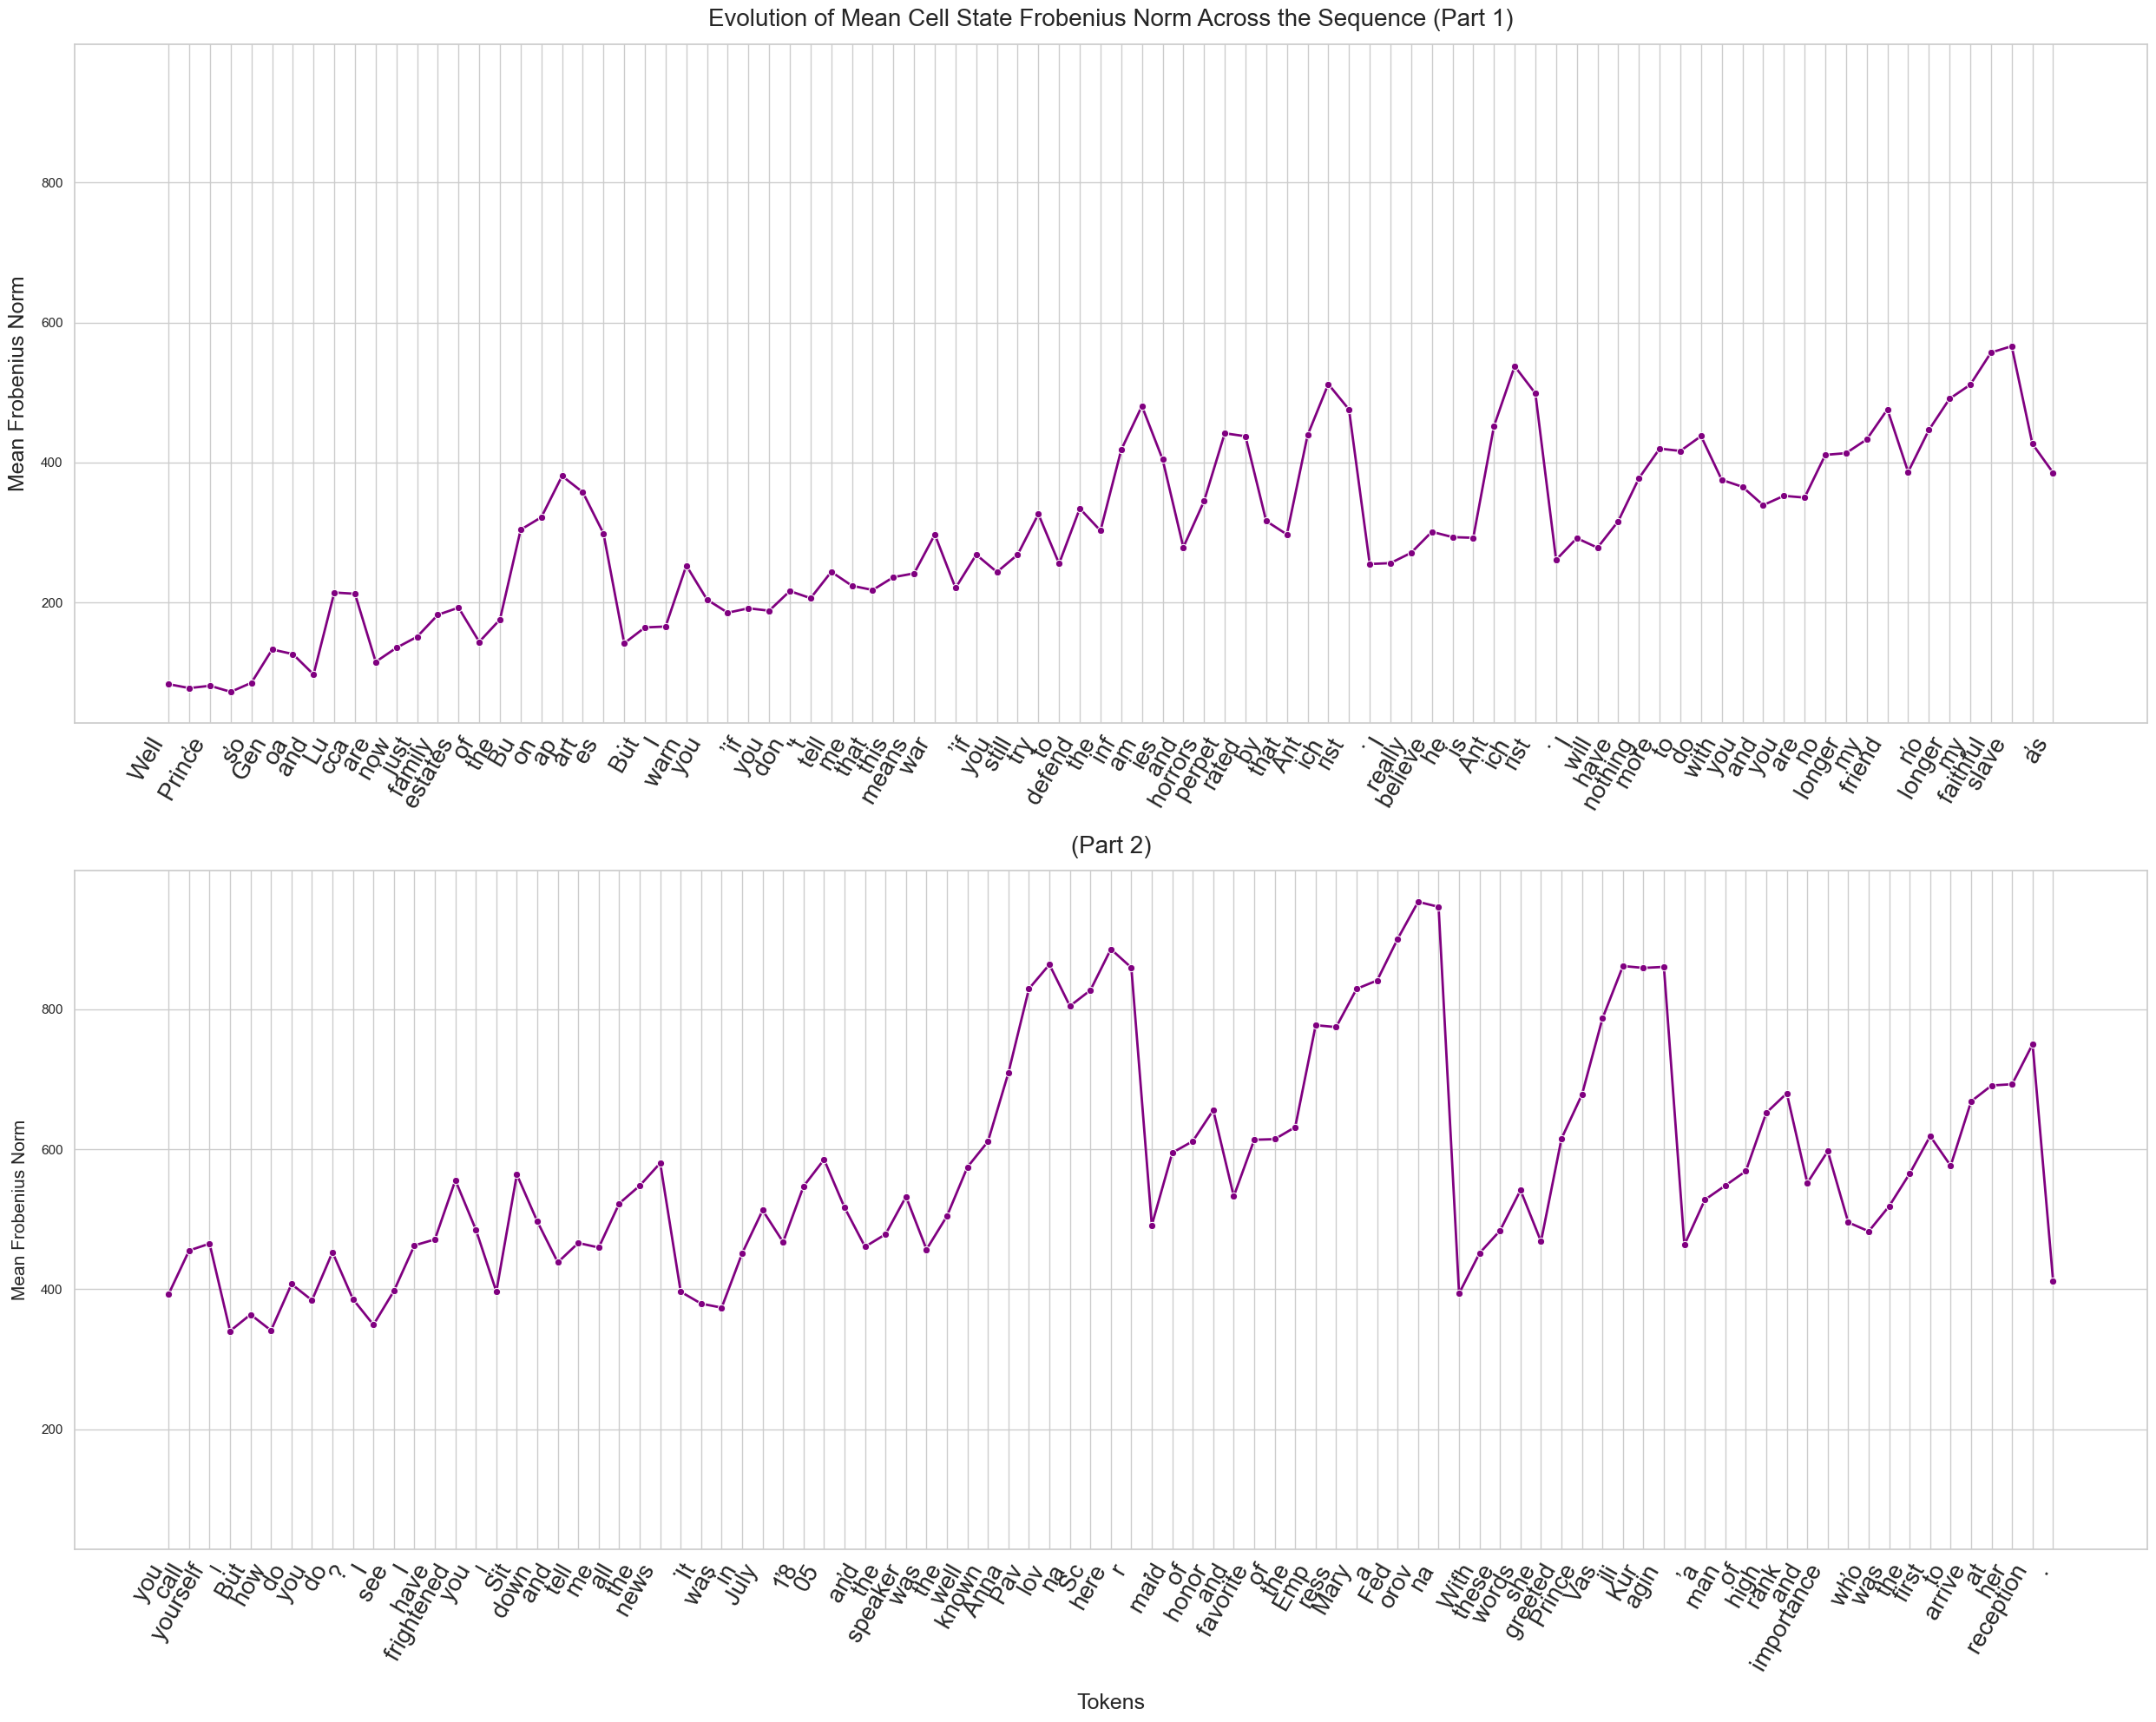

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a DataFrame for Seaborn
# (Assuming 'tokens' and 'Cfro_token_amean' are defined in your environment)
df = pd.DataFrame({
    'Token Index': range(len(tokens)),
    'Token': tokens,
    # Convert from tensor to numpy array
    'Mean Cell State Norm': Cfro_token_amean.numpy()
})

# 2. Split the DataFrame into two halves
mid_point = len(df) // 2
df_part1 = df.iloc[:mid_point]
df_part2 = df.iloc[mid_point:]

# 3. Set the Seaborn style
sns.set_theme(style="whitegrid")

# 4. Create the plot with 2 rows and 1 column
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(25, 20), sharey=True)

# --- PLOT 1 (First Half) ---
sns.lineplot(
    data=df_part1,
    x='Token Index',
    y='Mean Cell State Norm',
    marker="o",
    color="purple",
    linewidth=2,
    markersize=6,
    ax=ax1
)
ax1.set_xticks(df_part1['Token Index'])
ax1.set_xticklabels(df_part1['Token'], rotation=60, ha='right', fontsize=20)
ax1.set_title(
    "Evolution of Mean Cell State Frobenius Norm Across the Sequence (Part 1)", fontsize=20, pad=15)
ax1.set_ylabel("Mean Frobenius Norm", fontsize=18, labelpad=10)
ax1.set_xlabel("")  # Leave x-label off the top plot to keep it clean

# --- PLOT 2 (Second Half) ---
sns.lineplot(
    data=df_part2,
    x='Token Index',
    y='Mean Cell State Norm',
    marker="o",
    color="purple",
    linewidth=2,
    markersize=6,
    ax=ax2
)
ax2.set_xticks(df_part2['Token Index'])
ax2.set_xticklabels(df_part2['Token'], rotation=60, ha='right', fontsize=20)
ax2.set_title("(Part 2)", fontsize=20, pad=15)
ax2.set_ylabel("Mean Frobenius Norm", fontsize=15, labelpad=10)
ax2.set_xlabel("Tokens", fontsize=18, labelpad=10)

# Optional: Tight layout ensures the tilted labels don't get cut off
plt.tight_layout()

plt.savefig("../latex/images/c_t_norm_time_series.png")

# Show the plot!
plt.show()


d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


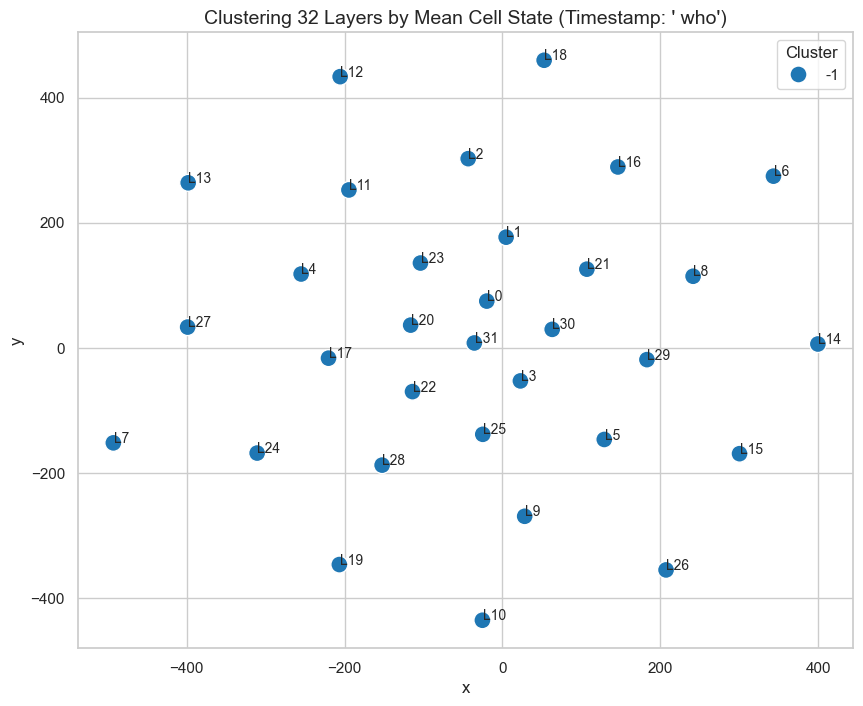

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import HDBSCAN

t = -1
token_word = tokens[t]

C_layers_at_t = C_matrix_all[:, 0, t, :, :]

num_layers = C_layers_at_t.shape[0] 
C_flattened_layers = C_layers_at_t.reshape(num_layers, -1).numpy()

tsne = TSNE(n_components=2, perplexity=8, random_state=42)
C_layers_tsne = tsne.fit_transform(C_flattened_layers)

clusterer = HDBSCAN(min_cluster_size=3)
labels = clusterer.fit_predict(C_flattened_layers)

df_layers = pd.DataFrame({
    'x': C_layers_tsne[:, 0],
    'y': C_layers_tsne[:, 1],
    'Cluster': labels,
    'Layer': range(num_layers)
})

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_layers, x='x', y='y', hue='Cluster', palette='tab10', s=150)

for i in range(len(df_layers)):
    plt.text(df_layers['x'][i] + 0.3, df_layers['y'][i], f"L{df_layers['Layer'][i]}", fontsize=10)

plt.title(f"Clustering {num_layers} Layers by Mean Cell State (Timestamp: '{token_word}')", fontsize=14)
plt.show()
